In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

# Exploratory Data Analysis on Retail Sales Data

### OIBSIP - Data Analytics Level 1 Task 1

**Objective:**  
Perform Exploratory Data Analysis (EDA) on retail sales data to identify
sales patterns, customer behaviour, product performance, and actionable
business insights.



In [4]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.shape           #to check the shape 

(1000, 9)

In [7]:
df.columns                  #to check the columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [8]:
df.dtypes                 #to check the datatypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df.isnull().sum()       #to check the missing values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
df.duplicated().sum()     #this is used to check how many completely duplicated rows exist.

np.int64(0)

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df['Date'].dtype

dtype('<M8[ns]')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [14]:
df.describe()       #used to check numerical columns

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


# Now we will calculate Mean, Median, Mode, and Standard Deviation for all numerical columns.

In [15]:
df.mean(numeric_only=True)           # This is used to calculates the average for every numerical column.


Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [16]:
df.median(numeric_only=True)       # This is used to calculate the median value

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [17]:
df.mode(numeric_only=True).iloc[0]      # This is used to Calculate the Mode value

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

# Creating one Summary Table

In [18]:
stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Standard Deviation': df.std(numeric_only=True)
})

stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics

The descriptive statistics summarize the central tendency and variability of the numerical variables in the retail sales dataset. Mean, median, mode, and standard deviation are used to understand the distribution of transaction values, customer ages, quantities, prices, and total sales.

## Time Series Analysis

Time series analysis is used to understand how sales change over time. In this section, we will analyze the monthly and quarterly sales trends using line charts.

In [19]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [20]:
monthly_sales = df.groupby(                                #Monthly Sales
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

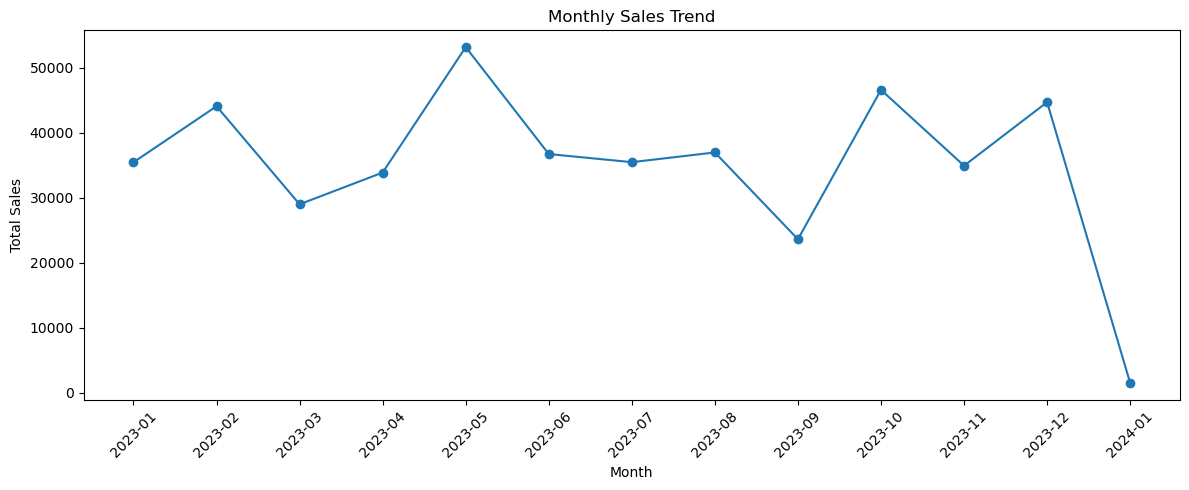

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows considerable fluctuations throughout the year. Sales reached their highest level in May 2023, at approximately 52,850, while September 2023 recorded the lowest sales among the complete months, at approximately 23,620. Sales increased sharply during some periods, particularly from April to May and from September to October, indicating variations in monthly customer demand. January 2024 has been excluded from the comparison of complete months because the dataset contains only one day of data for that month.

## Quarterly Sales Analysis

In [22]:
quarterly_sales = df.groupby(                             #Monthly and quarterly sales trends.
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

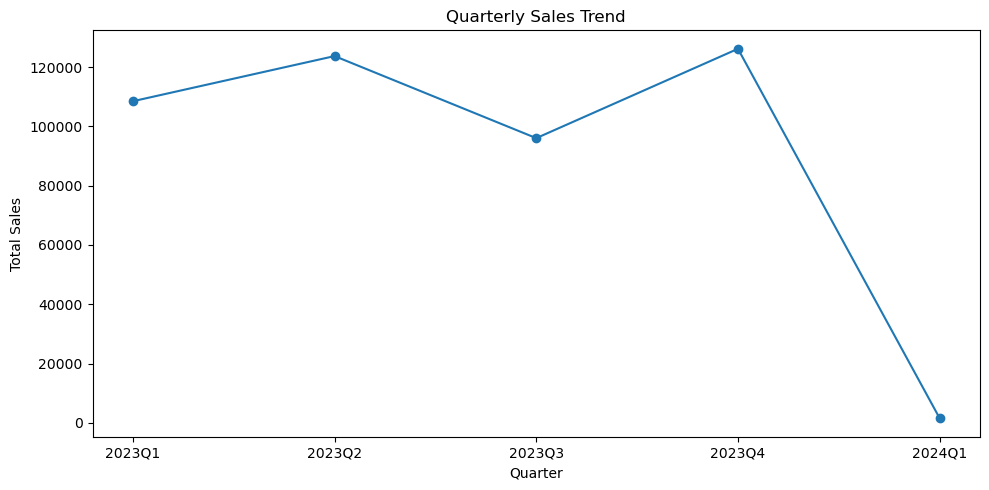

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend shows fluctuations in overall sales performance during 2023. Sales increased from 108,500 in Q1 to 123,735 in Q2, then declined to 96,485 in Q3. Sales recovered strongly in Q4 and reached the highest quarterly sales of 126,190. The sharp decline shown for 2024 Q1 should not be considered a true decline in business performance because the dataset contains only one day of data for this quarter.

## Customer Demographics Analysis

This section analyzes the customer base using age groups and gender distribution to understand the demographic characteristics of the retail customers.

In [24]:
bins = [18, 25, 35, 45, 55, 65]                                    #Creating the Age Groups
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df['Age Group'].value_counts().sort_index()

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64

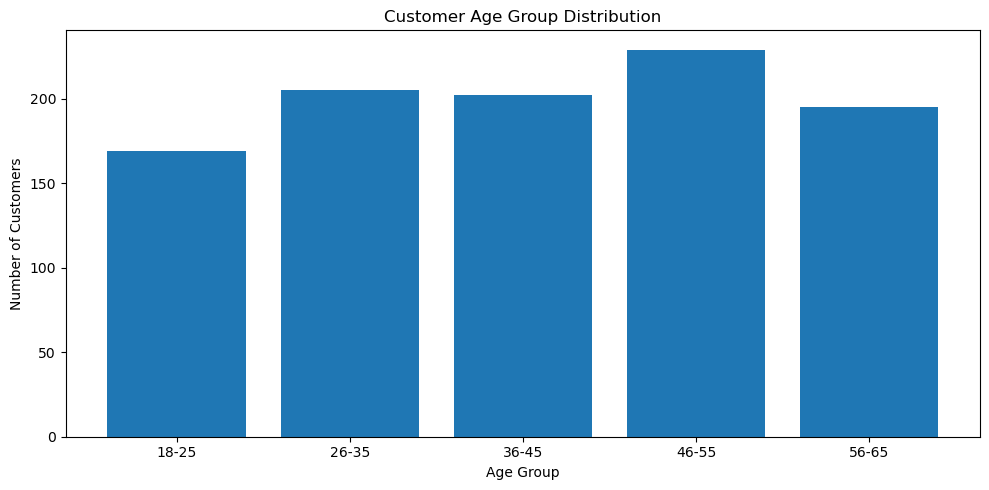

In [25]:
age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(age_group_counts.index, age_group_counts.values)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The customer age distribution is relatively balanced across all age groups. The 46–55 age group has the highest number of customers, with 229 customers, while the 18–25 age group has the lowest, with 169 customers. Overall, customers aged 26–55 represent a large portion of the customer base, indicating that this age range is an important segment for the retail business.

## Gender Analysis

In [26]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

## Gender Breakdown Chart

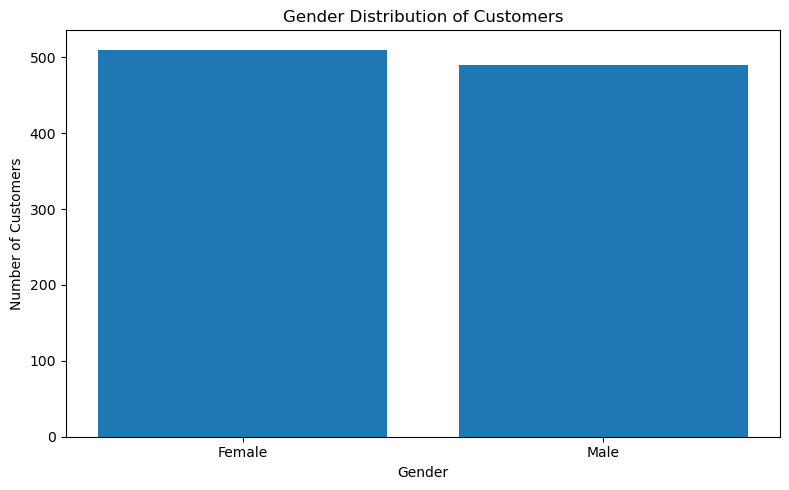

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The gender distribution is relatively balanced, with 510 female customers and 490 male customers. Female customers represent a slightly larger share of the customer base, accounting for approximately 51% of the transactions, while male customers account for approximately 49%. This indicates that the retail business has a fairly balanced customer base across genders.

## Product Analysis

This section analyzes product category performance using total sales revenue and quantity sold. The analysis helps identify which product categories contribute most to overall business performance.

## Revenue by Product Category

In [28]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

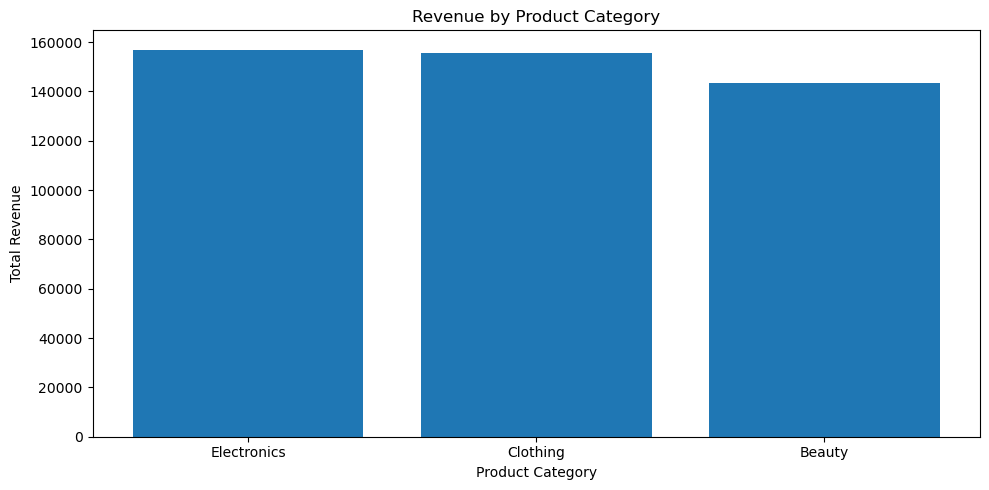

In [29]:
plt.figure(figsize=(10, 5))
                                                                      #Creating a revenue by Category chart
plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Observation

Electronics generated the highest revenue at 156,905, followed closely by Clothing at 155,580. Beauty generated the lowest revenue at 143,515. Overall, revenue is fairly evenly distributed across the three product categories, although Electronics has a slight lead over Clothing and Beauty.

### Quantity Sold by Category

In [30]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

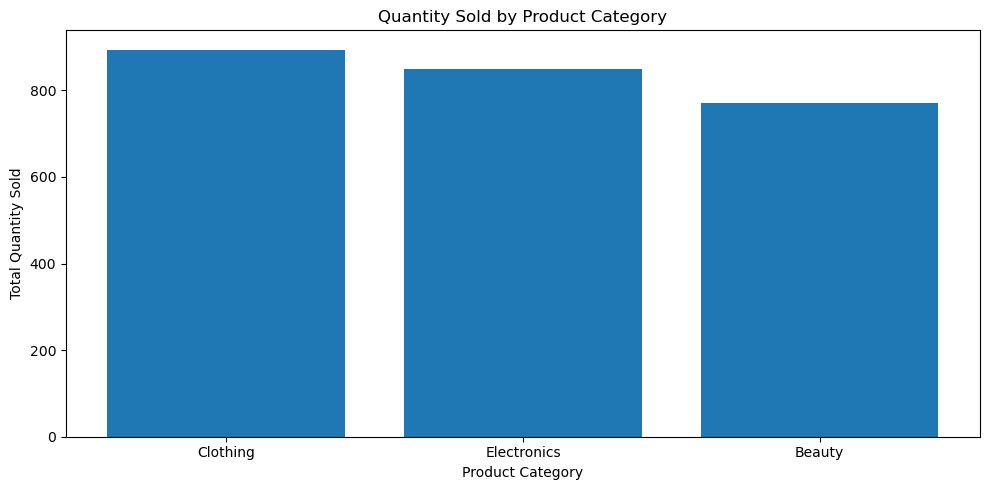

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(category_quantity.index, category_quantity.values)

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')

plt.tight_layout()
plt.show()

### Observation

Clothing has the highest sales volume with 894 units sold, followed by Electronics with 849 units and Beauty with 771 units. Although Clothing sells the most units, Electronics generates the highest revenue. This indicates that Electronics products may have a higher average selling price, making them more valuable in terms of revenue despite having slightly lower sales volume.

## Correlation Analysis

Correlation analysis is used to identify relationships between numerical variables in the retail sales dataset. A heatmap is used to visualize the strength and direction of these relationships.

In [32]:
correlation_matrix = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


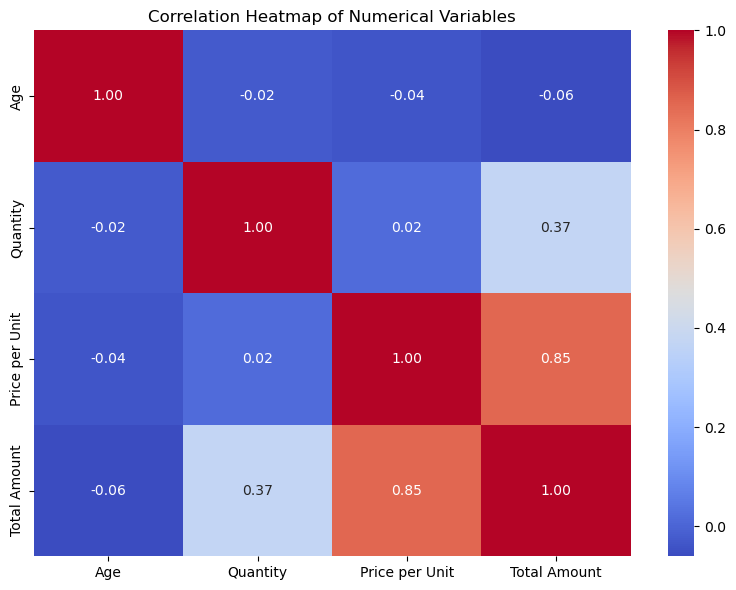

In [33]:
plt.figure(figsize=(8, 6))
                                        #Creating the heat map
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between Age, Quantity, Price per Unit, and Total Amount. Quantity and Total Amount show a positive relationship because higher quantities generally result in higher transaction values. Price per Unit also contributes to Total Amount, while Age shows relatively weak relationships with the other numerical variables. Overall, the heatmap helps identify which numerical factors are more closely associated with sales performance.

## Additional Visualization

## Calculate Revenue by Age Group

In [35]:
age_group_sales = df.groupby(
    'Age Group',
    observed=True
)['Total Amount'].sum().sort_values(ascending=False)

age_group_sales

Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-65     80410
Name: Total Amount, dtype: int64

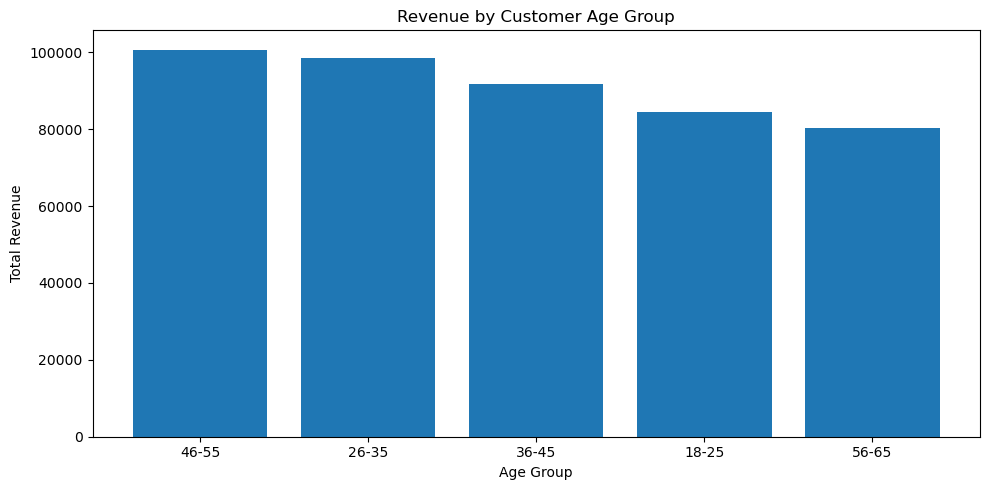

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(age_group_sales.index, age_group_sales.values)

plt.title('Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Observation

The revenue distribution across customer age groups shows differences in spending contribution among the segments. Comparing revenue with the number of customers helps identify which age groups generate higher sales value. This analysis can help the business focus marketing campaigns and promotional offers on age groups that contribute more to overall revenue.

## Conclusion and Business Recommendations

The exploratory data analysis provides useful insights into sales trends, customer demographics, and product category performance.

### Key Findings

- Electronics generated the highest revenue among the product categories, with total revenue of 156,905.
- Clothing recorded the highest quantity sold, with 894 units.
- The 46–55 age group had the highest number of customers, with 229 customers.
- Female customers were slightly higher in number than male customers, with 510 female and 490 male customers.
- Quarterly sales were highest in Q4 2023, with revenue of 126,190.
- Monthly sales showed considerable fluctuations throughout 2023.

### Business Recommendations

1. **Focus on high-revenue categories:** Electronics generated the highest revenue, so the business should maintain sufficient stock and consider targeted promotions for electronics products.

2. **Promote high-volume products:** Clothing recorded the highest quantity sold. The business should use bundle offers, cross-selling, and seasonal promotions to increase revenue from this category.

3. **Target the 26–55 age segment:** Customers between 26 and 55 form a major portion of the customer base. Marketing campaigns and personalized offers can be designed specifically for this age group.

4. **Use seasonal sales trends:** Sales fluctuate significantly across months and quarters. The business should increase inventory and promotional campaigns before historically strong sales periods.

5. **Maintain gender-balanced marketing:** Since the customer base is almost evenly split between female and male customers, marketing strategies should cater to both groups rather than focusing heavily on one gender.

In [38]:
# Inspecting the product-level dataset

product_df = pd.read_csv("global_ecommerce_sales.csv")

print("Shape of dataset:", product_df.shape)

print("\nColumn Names:")
print(product_df.columns.tolist())

print("\nFirst 5 Rows:")
display(product_df.head())

Shape of dataset: (2000, 15)

Column Names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method']

First 5 Rows:


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


## Top 10 Best-Selling Products

This analysis identifies the top 10 products based on the total quantity sold. It helps determine which individual products have the highest customer demand.

In [39]:
top_10_products = (
    product_df.groupby('Product_Name')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products

Product_Name
Wireless Ergonomic Mouse         238
Mechanical Gaming Keyboard       227
Folding Table Portable           226
Tablet Stand Holder              225
Smart LED Desk Lamp              222
Desk Calendar 2025               218
Standing Desk Converter          215
Mesh Back Task Chair             213
Wireless Bluetooth Headphones    212
Stapler Full-Size                211
Name: Quantity, dtype: int64

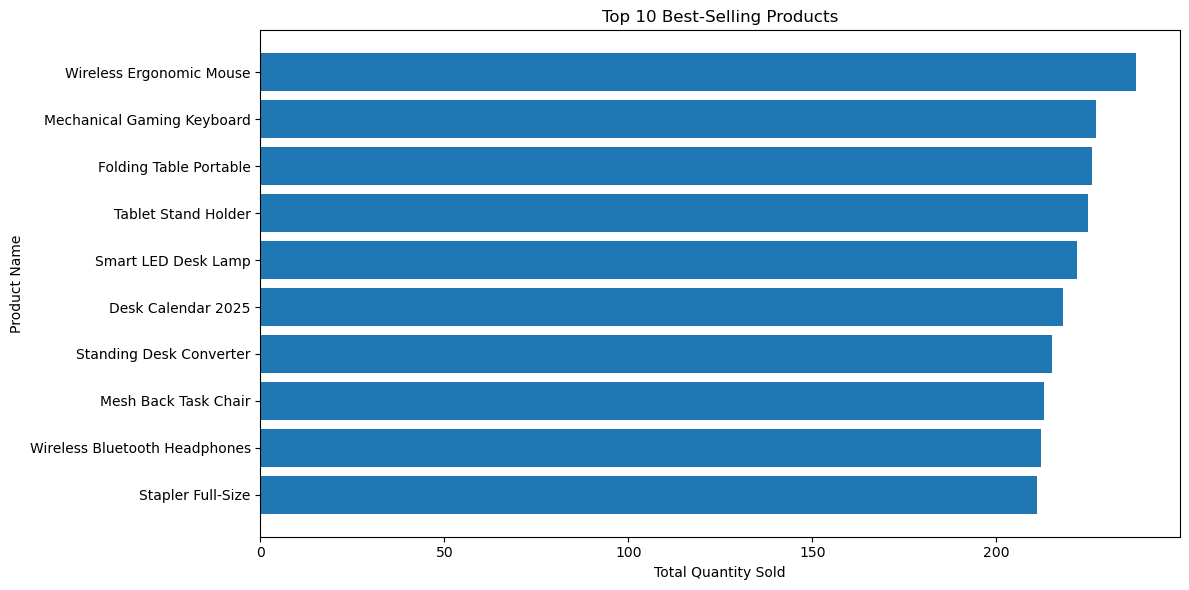

In [40]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_10_products.index[::-1],
    top_10_products.values[::-1]
)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

### Observation

The Top 10 best-selling products were identified based on total quantity sold. The analysis highlights the products with the highest customer demand and can help the business prioritize inventory, avoid stock-outs, and plan targeted promotions for high-demand products.

# Exploratory Data Analysis on Retail Sales Data

### OIBSIP - Data Analytics Level 1 Task 1

**Objective:**

Perform Exploratory Data Analysis (EDA) on retail sales data to identify sales patterns, customer behaviour, product performance, and actionable business insights.

**Tech Stack:**

Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook